# Generate Handwritten Digit Images using DCGAN


In [1]:
# If needed, uncomment to install dependencies
# !pip install matplotlib numpy

In [2]:
#%pip install torch torchvision torchaudio

## 1. Import Libraries

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
from IPython.display import display

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Hyperparameters

In [4]:
BATCH_SIZE   = 64     #increase (e.g. 256-512) for faster training and if u are using GPU
NUM_EPOCHS   = 5        # increase (e.g. 50-100) for even better quality if u are using GPU
LATENT_DIM   = 100       # size of the noise vector z
LR           = 0.0002    # learning rate (DCGAN paper)
BETA1        = 0.5       # Adam beta1 (DCGAN paper)
IMG_SIZE     = 28
NUM_CHANNELS = 1         # grayscale
OUTPUT_DIR   = "dcgan_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3. Load and Preprocess the MNIST Dataset
MNIST contains 60,000 training images (28x28, grayscale) of digits 0-9.  
Images are scaled to **[-1, 1]** so they match the `Tanh` output of the Generator.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),                  # [0, 1]
    transforms.Normalize((0.5,), (0.5,))    # [-1, 1]
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, drop_last=True
)

print("Training images:", len(train_dataset))
print("Batches per epoch:", len(dataloader))

Training images: 60000
Batches per epoch: 937


### Visualize some real training images

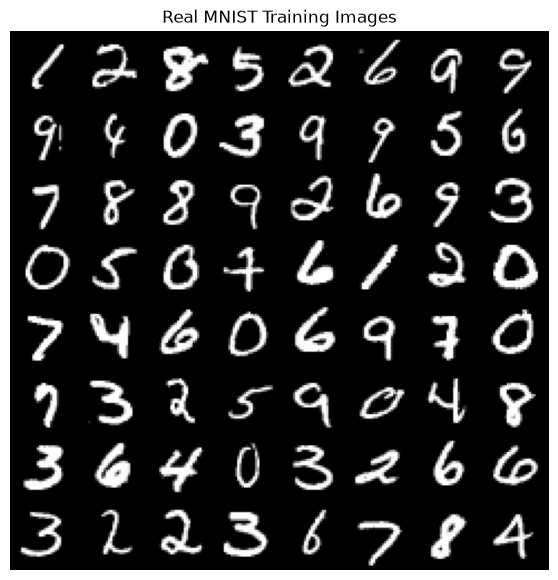

In [6]:
real_batch, real_labels = next(iter(dataloader))
plt.figure(figsize=(7, 7))
plt.axis("off")
plt.title("Real MNIST Training Images")
grid = vutils.make_grid(real_batch[:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()

## 4. Build the Models

### Generator
`z (100)` -> reshape `(100,1,1)` -> ConvTranspose -> `(256,7,7)` -> `(128,14,14)` -> `(1,28,28)`

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, channels=NUM_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # (latent_dim, 1, 1) -> (256, 7, 7)
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # (256, 7, 7) -> (128, 14, 14)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # (128, 14, 14) -> (64, 28, 28)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # (64, 28, 28) -> (1, 28, 28)
            nn.Conv2d(64, channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

### Discriminator
A CNN that maps `(1,28,28)` -> probability that the image is real.

In [8]:
class Discriminator(nn.Module):
    def __init__(self, channels=NUM_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # (1, 28, 28) -> (64, 14, 14)
            nn.Conv2d(channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (64, 14, 14) -> (128, 7, 7)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # (128, 7, 7) -> (256, 3, 3)
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # (256, 3, 3) -> (1, 1, 1)
            nn.Conv2d(256, 1, kernel_size=3, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)

### Initialize weights (N(0, 0.02) as in the DCGAN paper) and create the models

In [9]:
def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator().to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)
print("Generator params    :", sum(p.numel() for p in netG.parameters()))
print("Discriminator params:", sum(p.numel() for p in netD.parameters()))

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_s

## 5. Loss Function and Optimizers

In [10]:
criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise to track the generator's progress across epochs
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

## 6. Train the DCGAN
For each batch:
1. **Update D:** maximize `log D(x) + log(1 - D(G(z)))`
2. **Update G:** maximize `log D(G(z))`

Starting training...
[1/5][0/937] Loss_D: 1.6259  Loss_G: 1.3671  D(x): 0.458  D(G(z)): 0.535
[1/5][200/937] Loss_D: 0.7722  Loss_G: 1.6114  D(x): 0.602  D(G(z)): 0.181
[1/5][400/937] Loss_D: 0.5643  Loss_G: 1.5942  D(x): 0.685  D(G(z)): 0.115
[1/5][600/937] Loss_D: 0.6441  Loss_G: 2.6799  D(x): 0.897  D(G(z)): 0.378
[1/5][800/937] Loss_D: 0.8125  Loss_G: 1.8316  D(x): 0.715  D(G(z)): 0.349


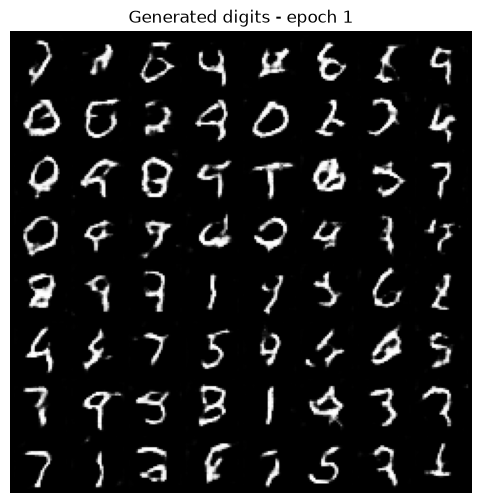

[2/5][0/937] Loss_D: 0.8798  Loss_G: 1.0813  D(x): 0.540  D(G(z)): 0.139
[2/5][200/937] Loss_D: 0.9463  Loss_G: 2.8326  D(x): 0.940  D(G(z)): 0.547
[2/5][400/937] Loss_D: 0.6771  Loss_G: 1.6308  D(x): 0.725  D(G(z)): 0.260
[2/5][600/937] Loss_D: 0.6973  Loss_G: 1.4262  D(x): 0.590  D(G(z)): 0.100
[2/5][800/937] Loss_D: 0.6912  Loss_G: 1.7978  D(x): 0.864  D(G(z)): 0.370
[3/5][0/937] Loss_D: 0.6126  Loss_G: 2.1610  D(x): 0.817  D(G(z)): 0.302
[3/5][200/937] Loss_D: 0.9638  Loss_G: 0.9826  D(x): 0.467  D(G(z)): 0.100
[3/5][400/937] Loss_D: 0.6357  Loss_G: 1.7640  D(x): 0.744  D(G(z)): 0.249
[3/5][600/937] Loss_D: 0.7684  Loss_G: 2.2468  D(x): 0.848  D(G(z)): 0.404
[3/5][800/937] Loss_D: 0.9560  Loss_G: 1.0209  D(x): 0.573  D(G(z)): 0.260
[4/5][0/937] Loss_D: 0.5529  Loss_G: 2.0088  D(x): 0.831  D(G(z)): 0.277
[4/5][200/937] Loss_D: 1.0157  Loss_G: 2.0101  D(x): 0.823  D(G(z)): 0.511
[4/5][400/937] Loss_D: 0.5922  Loss_G: 2.3674  D(x): 0.888  D(G(z)): 0.345
[4/5][600/937] Loss_D: 0.7641  

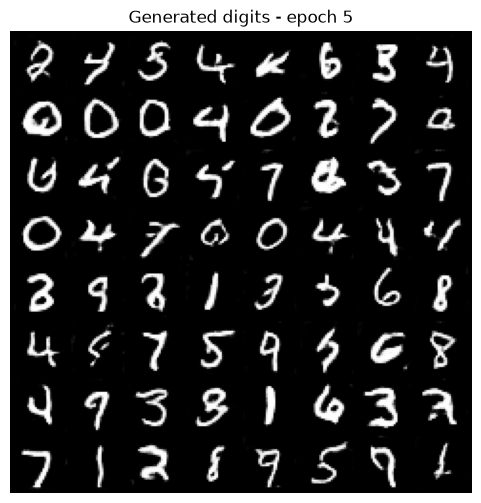

Training finished.


In [11]:
G_losses, D_losses = [], []
D_x_hist, D_G_z_hist = [], []
progress_images = []

def show_samples(epoch):
    netG.eval()
    with torch.no_grad():
        fake = netG(fixed_noise).cpu()
    netG.train()
    grid = vutils.make_grid(fake, padding=2, normalize=True)
    progress_images.append(grid)
    vutils.save_image(fake, f"{OUTPUT_DIR}/epoch_{epoch:03d}.png", nrow=8, normalize=True, padding=2)
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.title(f"Generated digits - epoch {epoch}")
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.show()

print("Starting training...")
for epoch in range(1, NUM_EPOCHS + 1):
    for i, (real, _) in enumerate(dataloader):
        b = real.size(0)
        real = real.to(device)

        # ---------- (1) Train Discriminator ----------
        netD.zero_grad()
        label_real = torch.full((b,), REAL_LABEL, device=device)
        out_real = netD(real)
        lossD_real = criterion(out_real, label_real)
        lossD_real.backward()

        noise = torch.randn(b, LATENT_DIM, 1, 1, device=device)
        fake = netG(noise)
        label_fake = torch.full((b,), FAKE_LABEL, device=device)
        out_fake = netD(fake.detach())
        lossD_fake = criterion(out_fake, label_fake)
        lossD_fake.backward()

        lossD = lossD_real + lossD_fake
        optimizerD.step()

        # ---------- (2) Train Generator ----------
        netG.zero_grad()
        label_g = torch.full((b,), REAL_LABEL, device=device)  # G wants D to say "real"
        out_g = netD(fake)
        lossG = criterion(out_g, label_g)
        lossG.backward()
        optimizerG.step()

        G_losses.append(lossG.item())
        D_losses.append(lossD.item())
        D_x_hist.append(out_real.mean().item())
        D_G_z_hist.append(out_fake.mean().item())

        if i % 200 == 0:
            print(f"[{epoch}/{NUM_EPOCHS}][{i}/{len(dataloader)}] "
                  f"Loss_D: {lossD.item():.4f}  Loss_G: {lossG.item():.4f}  "
                  f"D(x): {out_real.mean().item():.3f}  D(G(z)): {out_fake.mean().item():.3f}")

    if epoch == 1 or epoch % 5 == 0 or epoch == NUM_EPOCHS:
        show_samples(epoch)
    else:
        show_samples_silent = None
        netG.eval()
        with torch.no_grad():
            f = netG(fixed_noise).cpu()
        netG.train()
        progress_images.append(vutils.make_grid(f, padding=2, normalize=True))
        vutils.save_image(f, f"{OUTPUT_DIR}/epoch_{epoch:03d}.png", nrow=8, normalize=True, padding=2)

print("Training finished.")

## 7. Training Analysis

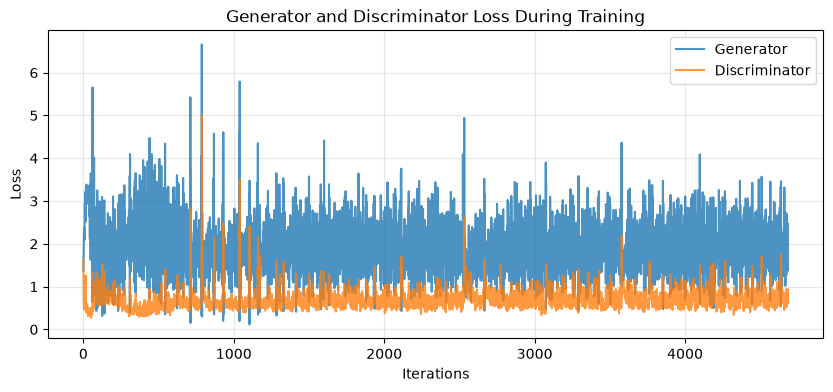

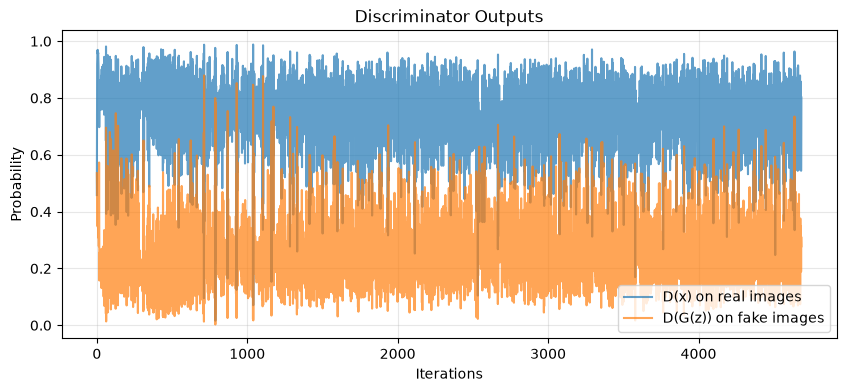

In [12]:
plt.figure(figsize=(10, 4))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator", alpha=0.8)
plt.plot(D_losses, label="Discriminator", alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.title("Discriminator Outputs")
plt.plot(D_x_hist, label="D(x) on real images", alpha=0.7)
plt.plot(D_G_z_hist, label="D(G(z)) on fake images", alpha=0.7)
plt.xlabel("Iterations")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Real vs Generated Images

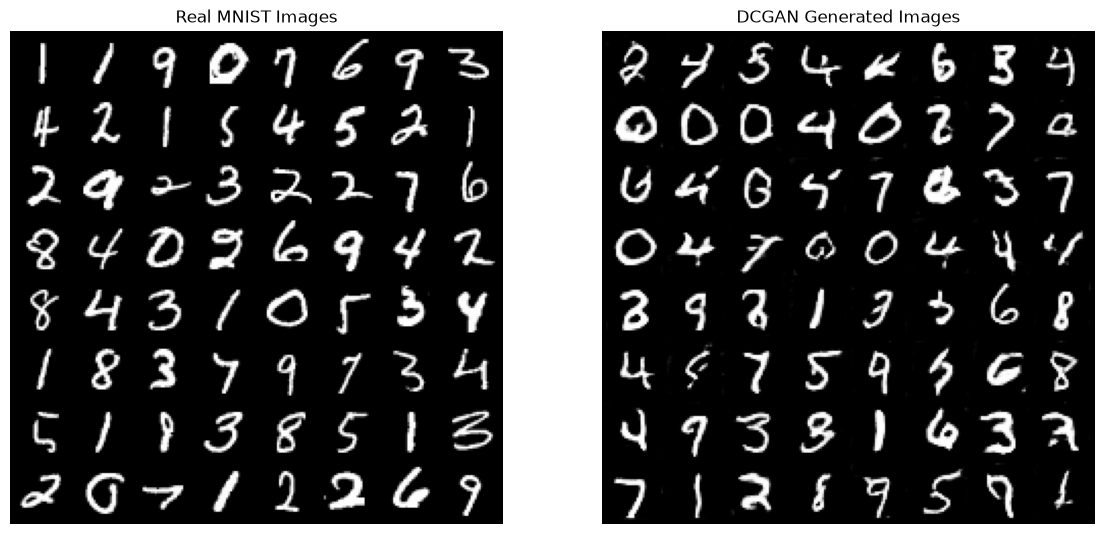

In [13]:
netG.eval()
with torch.no_grad():
    fake_final = netG(fixed_noise).cpu()

real_batch, _ = next(iter(dataloader))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].axis("off")
axes[0].set_title("Real MNIST Images")
axes[0].imshow(np.transpose(vutils.make_grid(real_batch[:64], padding=2, normalize=True).numpy(), (1, 2, 0)))
axes[1].axis("off")
axes[1].set_title("DCGAN Generated Images")
axes[1].imshow(np.transpose(vutils.make_grid(fake_final, padding=2, normalize=True).numpy(), (1, 2, 0)))
plt.show()

### Evolution of generated digits over epochs

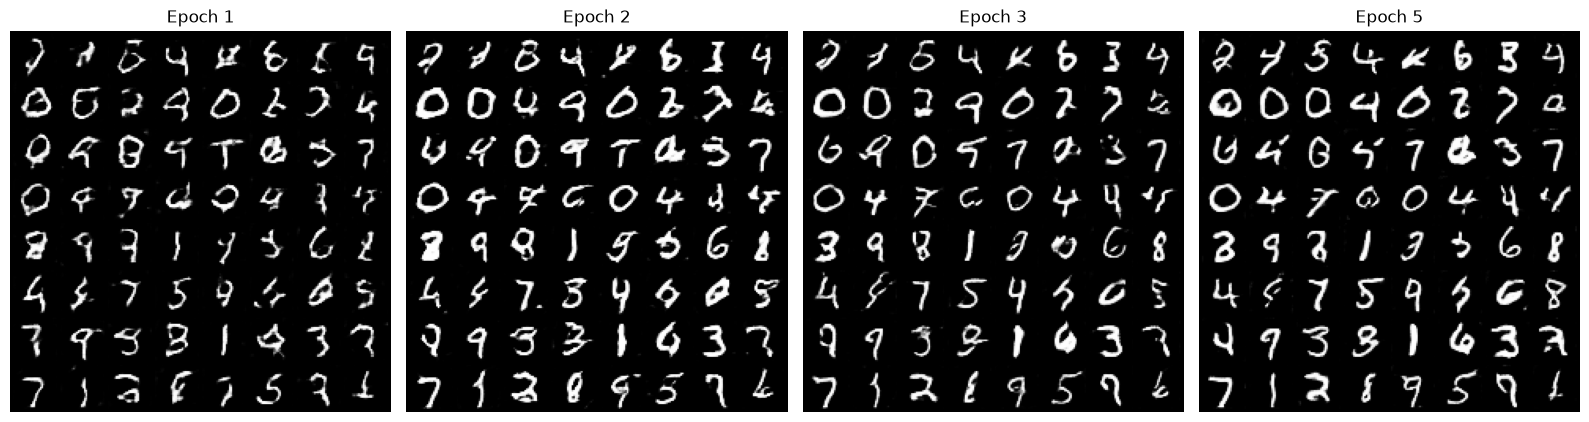

In [14]:
epochs_to_show = [0, 1, 4, 9, len(progress_images) // 2, len(progress_images) - 1]
epochs_to_show = sorted(set(e for e in epochs_to_show if 0 <= e < len(progress_images)))

fig, axes = plt.subplots(1, len(epochs_to_show), figsize=(4 * len(epochs_to_show), 4.5))
if len(epochs_to_show) == 1:
    axes = [axes]
for ax, idx in zip(axes, epochs_to_show):
    ax.axis("off")
    ax.set_title(f"Epoch {idx + 1}")
    ax.imshow(np.transpose(progress_images[idx].numpy(), (1, 2, 0)))
plt.tight_layout()
plt.show()

## 9. Generate New Handwritten Digits

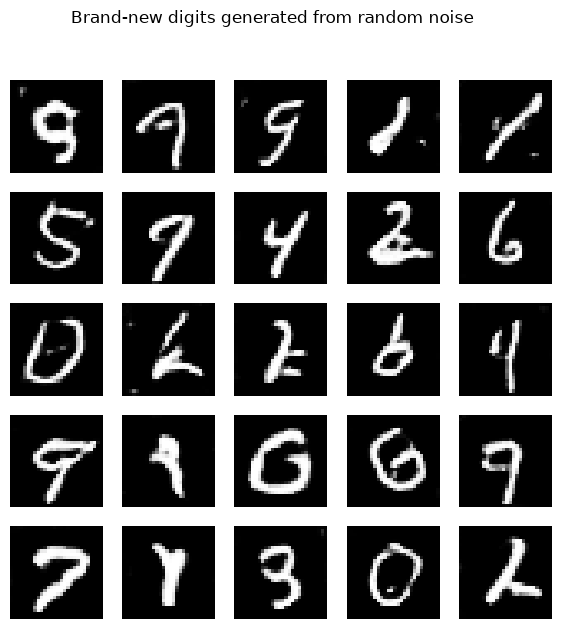

In [15]:
def generate_digits(n=25, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    netG.eval()
    z = torch.randn(n, LATENT_DIM, 1, 1, device=device)
    with torch.no_grad():
        imgs = netG(z).cpu()
    return imgs

imgs = generate_digits(25)
fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for ax, img in zip(axes.flatten(), imgs):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Brand-new digits generated from random noise")
plt.show()

### Latent space interpolation (smooth morphing between two random digits)

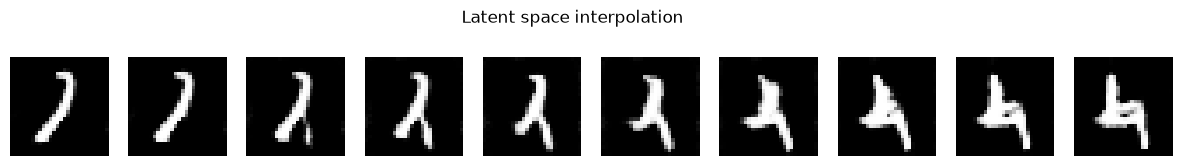

In [16]:
netG.eval()
z1 = torch.randn(1, LATENT_DIM, 1, 1, device=device)
z2 = torch.randn(1, LATENT_DIM, 1, 1, device=device)
steps = 10
alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1, 1, 1)
z_interp = (1 - alphas) * z1 + alphas * z2

with torch.no_grad():
    interp = netG(z_interp).cpu()

fig, axes = plt.subplots(1, steps, figsize=(15, 2))
for ax, img in zip(axes, interp):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Latent space interpolation")
plt.show()

## 10. Save the Trained Models and Create a GIF of Training Progress

In [17]:
torch.save(netG.state_dict(), f"{OUTPUT_DIR}/generator.pth")
torch.save(netD.state_dict(), f"{OUTPUT_DIR}/discriminator.pth")
print("Models saved in:", OUTPUT_DIR)

# Optional: GIF showing how the generator improved (needs: pip install imageio)
try:
    import imageio
    frames = [(np.transpose(g.numpy(), (1, 2, 0)) * 255).astype(np.uint8) for g in progress_images]
    imageio.mimsave(f"{OUTPUT_DIR}/dcgan_training.gif", frames, fps=4)
    print("GIF saved:", f"{OUTPUT_DIR}/dcgan_training.gif")
except ImportError:
    print("imageio not installed - skipping GIF (pip install imageio)")

Models saved in: dcgan_outputs
imageio not installed - skipping GIF (pip install imageio)


### Reload the saved generator (to use it later without retraining)

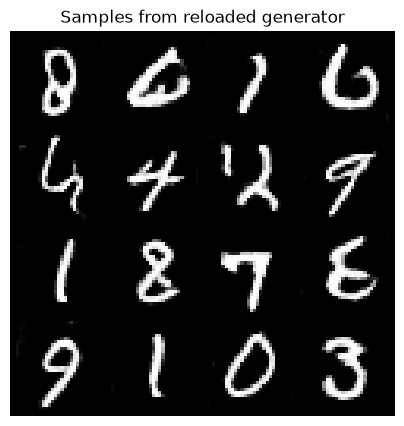

In [18]:
loaded_G = Generator().to(device)
loaded_G.load_state_dict(torch.load(f"{OUTPUT_DIR}/generator.pth", map_location=device))
loaded_G.eval()

with torch.no_grad():
    sample = loaded_G(torch.randn(16, LATENT_DIM, 1, 1, device=device)).cpu()
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.imshow(np.transpose(vutils.make_grid(sample, nrow=4, padding=2, normalize=True).numpy(), (1, 2, 0)))
plt.title("Samples from reloaded generator")
plt.show()